# 08. 최적화 함수

최적화 함수(Optimizer)는 역전파로 계산된 기울기를 이용해 모델 파라미터를 어떻게 갱신할지 결정하는 알고리즘이다.

1. 학습률이 파라미터 이동과 손실 변화에 미치는 영향을 확인한다.
2. SGD에서 Momentum, Adagrad, RMSProp, Adam으로 발전한 이유를 수식과 그래프로 비교한다.
3. PyTorch 학습 루프에서 `zero_grad()`, `backward()`, `step()`의 역할을 실제 모델과 연결한다.

## 1. 경사하강법과 학습률

현재 파라미터를 $w_t$, 손실의 기울기를 $g_t=\frac{\partial L}{\partial w_t}$, 학습률을 $\eta$라고 하면 가장 기본적인 갱신식은 다음과 같다.

$$
w_{t+1}=w_t-\eta g_t
$$

- 기울기가 양수이면 손실을 줄이기 위해 $w$를 감소시킨다.
- 기울기가 음수이면 손실을 줄이기 위해 $w$를 증가시킨다.
- 학습률은 한 번에 이동하는 크기를 조절한다.

학습률이 너무 작으면 수렴이 느리고, 너무 크면 최솟값을 지나쳐 진동하거나 발산할 수 있다.

### 손실 지형과 최소점

<img src="https://blog.kakaocdn.net/dn/b5qQXn/btrwZZbnLEh/33NmNUWcEOfr9Q7C2UOPOK/img.png" width="720">

위 그림에서 가로축은 가중치, 세로축은 손실이다.
optimizer는 현재 위치의 기울기를 이용해 아래쪽으로 이동하지만, 시작 위치와 손실 지형에 따라 가까운 **지역 최솟값(Local minimum)** 에 도달할 수 있다.
전체 지형에서 손실이 가장 낮은 지점은 **전역 최솟값(Global minimum)** 이다.

<img src="https://wngaw.github.io/images/local_vs_global_minima.png" width="760">

파라미터가 여러 개이면 손실함수는 위와 같은 고차원 지형으로 생각할 수 있다.
그림의 **Saddle Point(안장점)** 는 어떤 방향으로는 내려가고 다른 방향으로는 올라가는 지점이다.
기울기가 매우 작아 학습이 정체된 것처럼 보일 수 있지만 반드시 최솟값인 것은 아니다.

> MSE는 예측값 자체에 대해서는 볼록한 형태가 될 수 있지만, 여러 층을 가진 신경망의 파라미터에 대한 손실 지형은 일반적으로 비볼록하다.
> 따라서 딥러닝에서는 지역 최솟값뿐 아니라 안장점, 평평한 구간과 가파른 구간도 optimizer 동작에 영향을 준다.

### 실습 환경 준비

수동 갱신식과 PyTorch optimizer를 비교하기 위한 라이브러리를 불러오고 난수 시드를 고정한다.


In [1]:
import copy


import numpy as np


import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import torch.optim as optim


np.random.seed(42)
torch.manual_seed(42)

### 학습률에 따른 이동 경로

손실함수를 $L(w)=(w-3)^2$로 두면 최솟값은 $w=3$이다. 같은 시작점에서 학습률만 바꾸어 파라미터 이동과 손실 변화를 비교한다.

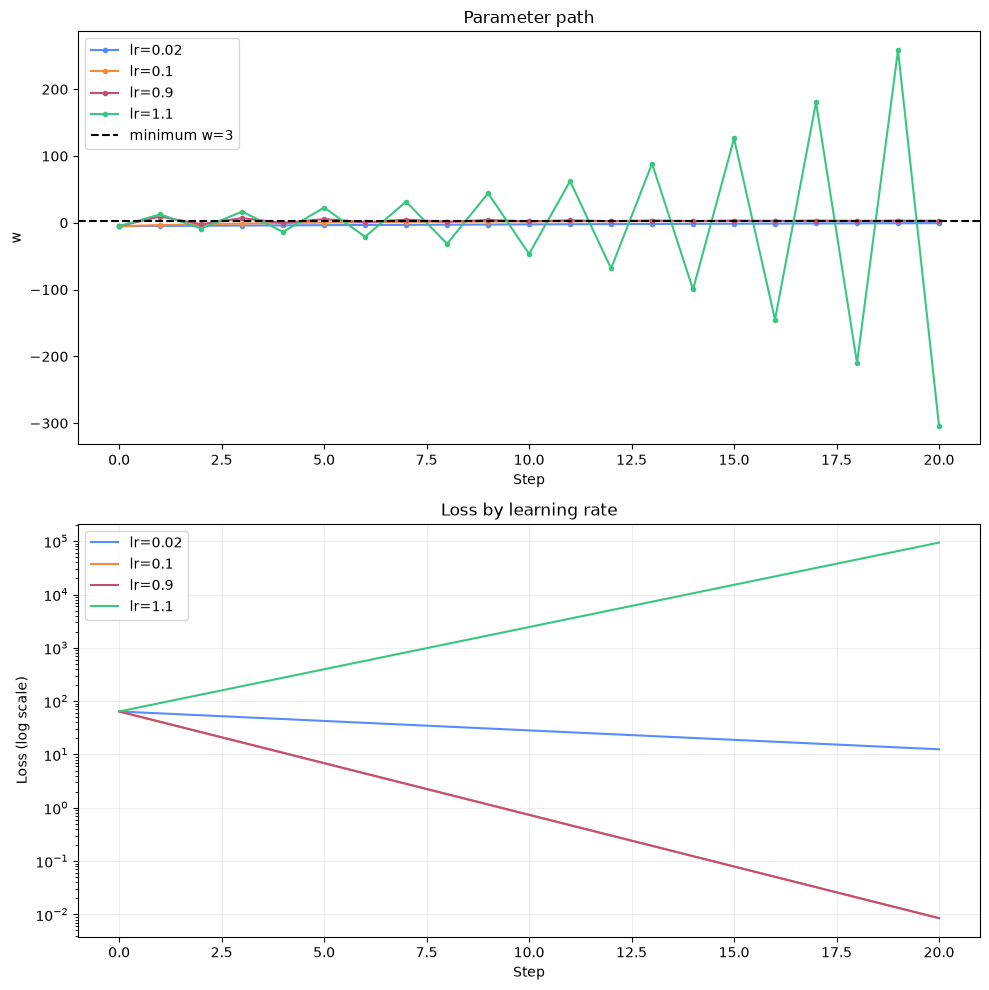

In [2]:
def quadratic_loss(w):
    return (w - 3.0) ** 2


def quadratic_gradient(w):
    return 2.0 * (w - 3.0)


learning_rates = [0.02, 0.1, 0.9, 1.1]


steps = 20


histories = {}


for learning_rate in learning_rates:
    w = -5.0


    weights = [w]
    losses = [quadratic_loss(w)]

    for _ in range(steps):

        # 기울기
        gradient = quadratic_gradient(w)

        # 기울기 * lr 만큼 기울기 감소
        w = w - learning_rate * gradient


        weights.append(w)
        losses.append(quadratic_loss(w))


    histories[learning_rate] = (weights, losses)


fig, axes = plt.subplots(2, 1, figsize=(10, 10))

for learning_rate, (weights, losses) in histories.items():

    axes[0].plot(weights, marker="o", markersize=3, label=f"lr={learning_rate}")


    axes[1].plot(np.array(losses) + 1e-12, label=f"lr={learning_rate}")


axes[0].axhline(3.0, color="black", linestyle="--", label="minimum w=3")
axes[0].set_title("Parameter path")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("w")
axes[0].legend()


axes[1].set_yscale("log")
axes[1].set_title("Loss by learning rate")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Loss (log scale)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. 주요 optimizer의 보완 관계

### optimizer에 따라 달라지는 이동 경로

<img src="https://d.pr/i/NWyaR6+" width="620">

위 애니메이션의 등고선은 같은 손실값을 가진 위치를 연결한 선이다. 검은 점은 시작 위치, 별은 도달하려는 낮은 손실 지점이며 색이 다른 경로는 optimizer별 파라미터 이동을 나타낸다.

- SGD(확률적 경사하강법)는 현재 기울기만 사용하므로 좁고 가파른 방향에서 좌우로 크게 흔들릴 수 있다.
- Momentum은 이전 이동 방향을 기억해 불필요한 진동을 줄이고 같은 방향의 이동을 가속한다.
- Adagrad와 RMSProp은 축마다 관찰된 기울기 크기를 이용해 보폭을 다르게 조절한다.

<img src="https://d.pr/i/hOcBKt+" width="620">

같은 과정을 3차원 손실 표면으로 보면 optimizer가 단순히 직선으로 내려가는 것이 아니라 손실 지형의 기울기와 곡률에 따라 서로 다른 경로를 선택한다는 점을 확인할 수 있다. 이 그림은 이동 원리를 보여주는 예시이며 특정 optimizer의 성능 순위를 의미하지 않는다. 실제 결과는 모델, 데이터, 초기값과 학습률에 따라 달라진다.

*이동 경로 애니메이션 출처: [An overview of gradient descent optimization algorithms](https://www.ruder.io/optimizing-gradient-descent/)*

### optimizer의 발전 흐름

<img src="https://d.pr/i/aeZ34p+" width="850">

위 관계도에서는 optimizer가 크게 **이동 방향을 보정하는 방법**과 **파라미터별 보폭을 조절하는 방법**으로 발전한 흐름을 볼 수 있다.
`SGD → Momentum`의 방향 보정과 `Adagrad → RMSProp`의 보폭 조절을 이해한 뒤, 두 아이디어를 결합한 Adam으로 연결한다.
AdamW, RAdam과 AdamP는 Adam 이후의 확장 알고리즘이다.

### 핵심 수식

**Momentum**은 이전 이동 방향을 누적한다.

$$
v_t=\beta v_{t-1}+g_t, \qquad w_{t+1}=w_t-\eta v_t
$$

**Adagrad**는 과거 기울기 제곱을 누적해 파라미터별 보폭을 조절한다.

$$
r_t=r_{t-1}+g_t^2, \qquad
w_{t+1}=w_t-\eta\frac{g_t}{\sqrt{r_t}+\epsilon}
$$

**RMSProp**은 최근 기울기 제곱에 더 큰 비중을 둔다.

$$
r_t=\rho r_{t-1}+(1-\rho)g_t^2
$$

<img src="https://d.pr/i/ywUzvV+" width="520">

RMSProp은 $r_t$에 과거 기울기 제곱을 전부 같은 비중으로 더하지 않는다. $\rho$가 0.9라면 이전 상태의 90%와 현재 기울기 제곱의 10%를 섞는다. 오래된 기울기의 영향은 반복할수록 작아지므로 Adagrad처럼 분모가 계속 커져 학습이 거의 멈추는 현상을 완화한다.

**Adam 알고리즘**
Momentum처럼 기울기의 이동 방향(기울기의 이동평균)을 기억하고, RMSProp(기울기 제곱의 이동평균)처럼 파라미터별 보폭을 조절한다.
두 모멘트를 함께 사용하여 비교적 빠르고 안정적으로 가중치를 갱신하는 optimizer이다.

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
$$

$$
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2
$$

| Optimizer | 기억하는 값 | 핵심 효과 | 주의할 점 |
| --- | --- | --- | --- |
| SGD | 현재 기울기 | 단순하고 해석하기 쉬움 | 학습률에 민감하고 진동 가능 |
| Momentum | 이전 이동 방향 | 같은 방향 가속, 진동 완화 | momentum 값 조정 필요 |
| Adagrad | 기울기 제곱 누적합 | 파라미터별 학습률 적용 | 후반 학습률이 지나치게 작아질 수 있음 |
| RMSProp | 최근 기울기 제곱 평균 | Adagrad의 지속 감소 완화 | decay와 학습률 조정 필요 |
| Adam | 1차·2차 모멘트 | 빠르고 안정적인 초기 학습 | 항상 최고의 일반화를 보장하지 않음 |

Adam의 $v_t$는 엄밀히 말해 실제 분산이 아니라 **기울기 제곱의 비중심 2차 모멘트 추정값**이다.

### 주요 optimizer 수동 갱신 비교

동일한 손실함수와 시작점에서 SGD, Momentum, Adagrad, RMSProp과 Adam의 갱신 방식을 직접 계산한다.

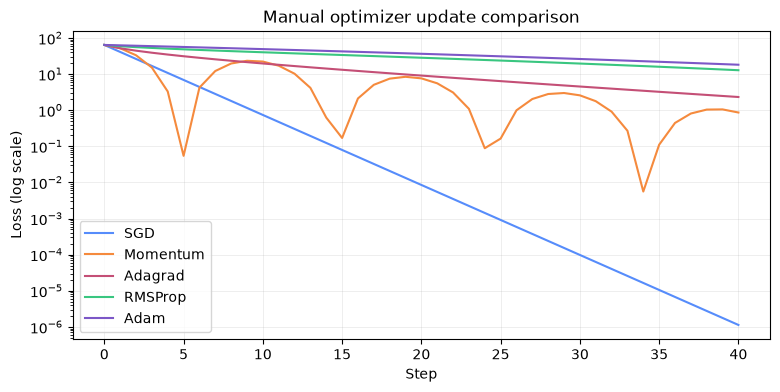

In [3]:
# optimizer마다 적절한 learning rate가 다르기 때문에 각각 지정
settings = {
    "SGD": {"lr": 0.10},
    "Momentum": {"lr": 0.05},
    "Adagrad": {"lr": 0.80},
    "RMSProp": {"lr": 0.10},
    "Adam": {"lr": 0.10},
}

optimizer_histories = {}

steps = 40

for name, setting in settings.items():

    # optimizer를 하나씩 꺼낼 때마다 모든 값 초기화
    w = -5.0            # 가중치
    momentum = 0.0      # 이전 기울기 반향을 누적해서 기억하는 값

    squared_sum = 0.0   # 기울기의 제곱을 기억하는 값(Adagrad, RMSProp)

    # Adam
    first_moment = 0.0  # 기울기의 이동 평균인 1차 모멘트 값
    second_moment = 0.0 # 기울기의 제곱 평균인 2차 모멘트 값

    # 최적화 전 손실을 기록
    losses = [quadratic_loss(w)]

    for step in range(1, steps + 1):
        gradient = quadratic_gradient(w)
        learning_rate = setting["lr"]

        if name == "SGD":
            w -= learning_rate * gradient

        elif name == "Momentum":
            momentum = 0.9 * momentum + gradient
            w -= learning_rate * momentum

        elif name == "Adagrad":
            squared_sum += gradient ** 2
            w -= learning_rate * gradient / (np.sqrt(squared_sum) + 1e-8)

        elif name == "RMSProp":
            squared_sum = 0.9 * squared_sum + 0.1 * gradient ** 2
            w -= learning_rate * gradient / (np.sqrt(squared_sum) + 1e-8)

        elif name == "Adam":
            first_moment = 0.9 * first_moment + 0.1 * gradient
            second_moment = 0.999 * second_moment + 0.001 * gradient ** 2
            corrected_first = first_moment / (1 - 0.9 ** step)
            corrected_second = second_moment / (1 - 0.999 ** step)
            w -= learning_rate * corrected_first / (np.sqrt(corrected_second) + 1e-8)

        losses.append(quadratic_loss(w))

    optimizer_histories[name] = losses


plt.figure(figsize=(9, 4))
for name, losses in optimizer_histories.items():
    plt.plot(np.array(losses) + 1e-12, label=name)


plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss (log scale)")
plt.title("Manual optimizer update comparison")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 3. PyTorch에서 optimizer 사용하기

PyTorch optimizer는 모델의 파라미터를 전달받아 `.grad`에 저장된 기울기를 사용한다.

```python
optimizer.zero_grad()  # 이전 기울기 초기화
prediction = model(X)  # 순전파
loss = criterion(prediction, y)
loss.backward()        # 기울기 계산
optimizer.step()       # 파라미터 갱신
```

SGD와 Adam을 공정하게 비교하려면 모델 구조뿐 아니라 **초기 가중치와 학습 데이터도 같아야 한다.**

### 동일한 초기 조건의 SGD·Adam 모델 준비

같은 데이터를 사용하고 `deepcopy`로 초기 가중치가 동일한 두 회귀 모델을 준비한다.

In [4]:
torch.manual_seed(42)

X = torch.randn(200, 3)

# 정답 데이터를 만들 떄 사용할 가중치
true_weight = torch.tensor([[2.0], [-1.0], [0.5]])

# 정답
y = X @ true_weight + 0.3 + 0.1 * torch.randn(200, 1)

base_model = nn.Linear(3, 1)

sgd_model = copy.deepcopy(base_model)
adam_model = copy.deepcopy(base_model)

sgd_optimizer = optim.SGD(sgd_model.parameters(), lr=0.05)
adam_optimizer = optim.Adam(adam_model.parameters(), lr=0.05)

print("입력 shape:", X.shape)
print("정답 shape:", y.shape)
print("초기 가중치 동일:", torch.equal(sgd_model.weight, adam_model.weight))

입력 shape: torch.Size([200, 3])
정답 shape: torch.Size([200, 1])
초기 가중치 동일: True


### 동일한 학습 루프로 SGD와 Adam 학습

두 모델에 같은 손실함수와 학습 단계를 적용하고 optimizer의 갱신 방식만 다르게 비교한다.

In [6]:
criterion = nn.MSELoss()    # 회귀 모델용 손실 함수

def train_model(model, optimizer, epochs=100):

    losses = [] # loss 저장 리스트

    model.train()   # 학습 모드

    for _ in range(epochs):
        optimizer.zero_grad()   # 기울기 초기화

        prediction = model(X)   # 예측

        loss = criterion(prediction, y) # loss 계산

        loss.backward() # 역전차(W,b의 기울기 계산(미분))

        optimizer.step()    # 파라미터 갱신(최적화) -> W,b 수정

        losses.append(loss.item())

    return losses   # epohs 수치만큼 반복하여 생성된 loss 기록을 반환

In [7]:
sgd_losses = train_model(sgd_model, sgd_optimizer)
adam_losses = train_model(adam_model, adam_optimizer)

print(f"SGD final loss: {sgd_losses[-1]:.6f}")
print(f"Adam final loss: {adam_losses[-1]:.6f}")

SGD final loss: 0.009402
Adam final loss: 0.009782


### 손실 곡선과 학습된 가중치 비교

epoch별 MSE 감소 과정과 두 모델이 학습한 가중치가 실제 가중치에 가까워졌는지 확인한다.

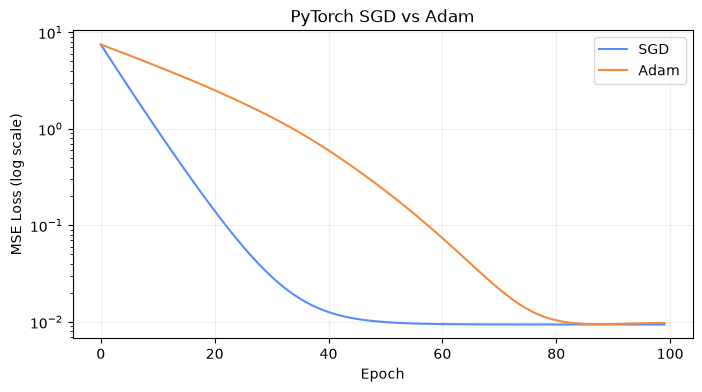

True weight: [2.0, -1.0, 0.5]
SGD weight: [2.0074193477630615, -0.9963891506195068, 0.5041494369506836]
Adam weight: [2.026869058609009, -0.9980248212814331, 0.5028502345085144]


In [8]:
plt.figure(figsize=(8, 4))
plt.plot(sgd_losses, label="SGD")
plt.plot(adam_losses, label="Adam")

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log scale)")
plt.title("PyTorch SGD vs Adam")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("True weight:", true_weight.squeeze().tolist())

print("SGD weight:", sgd_model.weight.detach().squeeze().tolist())
print("Adam weight:", adam_model.weight.detach().squeeze().tolist())

## 핵심 정리

- `loss.backward()`는 기울기를 계산하고 `optimizer.step()`은 파라미터를 갱신한다.
- 학습률이 너무 크면 진동·발산하고 너무 작으면 학습이 느려진다.
- Momentum은 이동 방향, RMSProp은 최근 기울기 제곱, Adam은 두 종류의 이동평균을 사용한다.
- optimizer 비교에서는 초기 가중치, 데이터 순서와 평가 기준을 통제해야 한다.
- optimizer가 학습률을 파라미터별로 조정하는 것과 scheduler가 epoch에 따라 전체 학습률을 바꾸는 것은 다른 개념이다.

### 확인 문제

1. `backward()`와 `step()`의 역할은 어떻게 다른가?
2. 학습률이 너무 클 때 손실 곡선에는 어떤 현상이 나타나는가?
3. Momentum과 RMSProp은 각각 무엇을 기억하는가?
4. Adam이 항상 SGD보다 좋은 것은 아닌 이유는 무엇인가?